In [1]:
NAME = "Min Cheah"

---

# Lab 7: Dimensionality Reduction

**Please read the following instructions very carefully**

## Working on the assignment / FAQs
- **Always use the seed/random_state as *42* wherever applicable** (This is to ensure repeatability in answers, across students and coding environments)
- The type of question and the points they carry are indicated in each question cell
- To avoid any ambiguity, each question also specifies what *value* must be set. Note that these are dummy values and not the answers
- If an autograded question has multiple answers (due to differences in handling NaNs, zeros etc.), all answers will be considered.
- You can delete the `raise NotImplementedError()`
- **Submitting the assignment** : Download the '.ipynb' file and the PDF file from Colab and upload it to Gradescope. Do not delete any outputs from cells before submitting.
- That's about it. Happy coding!


Available software:
 - Python's Gensim module: https://radimrehurek.com/gensim/ (install using pip)
 - Sklearn’s  TSNE module in case you use TSNE to reduce dimension (optional)
 - Python’s Matplotlib (optional)

_Note: The most important hyper parameters of skip-gram/CBOW are vector size and windows size_


In [2]:
!pip install gensim

import pandas as pd
import numpy as np
import gensim
import requests
import string

from IPython.display import Image
from sklearn.manifold import TSNE

# To make the visualizations
!git clone https://github.com/CAHLR/d3-scatterplot.git
from google.colab.output import eval_js
from IPython.display import Javascript
from gensim.models import KeyedVectors

# To download trained model (Google news)
import gensim.downloader as api
google_model = api.load('word2vec-google-news-300')

import nltk
from nltk import word_tokenize, tokenize
nltk.download('punkt')

Cloning into 'd3-scatterplot'...
remote: Enumerating objects: 1068, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 1068 (delta 32), reused 0 (delta 0), pack-reused 1016 (from 1)
Receiving objects: 100% (1068/1068), 1.97 MiB | 3.60 MiB/s, done.
Resolving deltas: 100% (621/621), done.
[==================================================] 100.0% 1662.8/1662.8MB downloaded


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

### **Q1** (0.25 points)
Download your text corpus. (A good place to start is the [nltk corpus](http://www.nltk.org/nltk_data/) or the [gutenberg project](https://www.gutenberg.org/))

In [3]:
#your code here
import nltk
nltk.download('gutenberg')  # Download the Gutenberg corpus if not already downloaded
from nltk.corpus import gutenberg

# Choose a text file from the Gutenberg corpus (e.g., 'austen-emma.txt')
raw = gutenberg.raw('austen-emma.txt')


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


In [4]:
#Save the raw text that you just downloaded in this variable
raw = gutenberg.raw('austen-emma.txt')

In [5]:
#This is an autograded cell, do not edit/delete
print(raw[:1000])

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.  Her mother
had died too long ago for her to have more than an indistinct
remembrance of her caresses; and her place had been supplied
by an excellent woman as governess, who had fallen little short
of a mother in affection.

Sixteen years had Miss Taylor been in Mr. Woodhouse's family,
less as a governess than a friend, very fond of both daughters,
but particularly of Emma.  Between _them_ it was more the intimacy
of sisters.  Even before Miss Taylor had ceased to hold the nominal
office of governess, the mildness o

### **Q2** (0.25 points)
Tokenize your corpus. Make sure that that the result is a list of lists i.e. The top-level list (outer list) is a list of sentences, and the inner list is a list of words in a given sentence.

Consider the following text:

```
text = "I spent $15.35 on my lunch today. Food in Berkeley is very expensive!"
```

It could be tokenized as follows:

```
tok_corp = [['I', 'spent', '$', '15.35', 'on', 'my', 'lunch', 'today'],
 ['Food', 'in', 'Berkeley', 'is', 'very', 'expensive']]
```


Note: There are many different (and correct) ways of tokenizing. Your answer doesn't need to match exactly with this illustrative example.

In [6]:
#code here
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download('punkt_tab')

sentences = sent_tokenize(raw)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [7]:
#Save the tokenized sentences as a list of list in this variable
tok_corp = [word_tokenize(sentence) for sentence in sentences]

In [8]:
#This is an autograded cell, do not edit/delete
for sent in tok_corp[:3]:
  print(sent)
  print("\n")

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']


['She', 'was', 'the', 'youngest', 'of', 'the', 'two', 'daughters', 'of', 'a', 'most', 'affectionate', ',', 'indulgent', 'father', ';', 'and', 'had', ',', 'in', 'consequence', 'of', 'her', 'sister', "'s", 'marriage', ',', 'been', 'mistress', 'of', 'his', 'house', 'from', 'a', 'very', 'early', 'period', '.']


['Her', 'mother', 'had', 'died', 'too', 'long', 'ago', 'for', 'her', 'to', 'have', 'more', 'than', 'an', 'indistinct', 'remembrance', 'of', 'her', 'caresses', ';', 'and', 'her', 'place', 'had', 'been', 'supplied', 'by'

### **Q3** (0.25 points)
Train gensim using your own dataset. Name the trained model variable as `model`.



In [9]:
#code here
from gensim.models import Word2Vec

model = Word2Vec(sentences=tok_corp, vector_size=100, window=5, min_count=1, workers=4, sg=0)
model.build_vocab(tok_corp)
model.train(tok_corp, total_examples=model.corpus_count, epochs=model.epochs)


(653143, 959285)

In [10]:
#This is an autograded cell, do not edit/delete
print(f'Corpus Size: {model.corpus_total_words}')
print(f'Corpus Count: {model.corpus_count}')
print(f'Training time: {model.total_train_time}')
print(f'Sample words: {list(model.wv.index_to_key[:10])}')

Corpus Size: 191857
Corpus Count: 7493
Training time: 3.7784819359995936
Sample words: [',', '.', 'to', 'the', 'and', 'of', 'I', '--', 'a', "''"]


### **Q4** (0.25 points)



#### **Q4a**

Create a list of the unique set of words from your corpus. Name the list variable as `unique_words`.


In [11]:
#code here
unique_words = list(set(word for sentence in tok_corp for word in sentence))

In [12]:
#This is an autograded cell, do not edit/delete
print(unique_words[:10])

['transaction', 'forever', 'seem', 'route', 'unceremoniousness', 'overrated', 'soliloquy', 'trade', 'inseparably', 'discuss']


#### **Q4b**

Extract respective vectors corresponding to the words in your corpus and store the vectors in a variable called `vector_list`.

In [13]:
#code here
vector_list = [model.wv[word] for word in unique_words if word in model.wv]

In [14]:
#This is an autograded cell, do not edit/delete
print(f'Array Shape: {np.array(vector_list).shape}')
for i in range(5):
    print(unique_words[i], vector_list[i])

Array Shape: (8375, 100)
transaction [-9.72222257e-03  4.45327628e-03  3.24715371e-03 -2.03673705e-03
 -3.69309145e-03 -1.33059882e-02  1.25867305e-02  1.27203781e-02
 -2.80204248e-02 -9.57220793e-03 -1.18861217e-02 -1.13499514e-03
 -1.32141272e-02  1.19384518e-02 -1.91050805e-02 -5.91657311e-03
  3.06607690e-05 -5.58686815e-03 -1.23437336e-02 -2.28501540e-02
  1.35019431e-02  2.36922652e-02 -9.92595032e-03  4.57206089e-03
 -4.06621164e-03 -1.62421037e-02 -1.85628943e-02 -5.21207880e-03
  6.81348005e-03  2.10776571e-02  6.10212702e-03  4.73679695e-03
 -3.11614550e-03  1.14962098e-03 -7.54569471e-03  3.04935463e-02
 -3.42504267e-04 -4.37137205e-03  1.15374327e-02 -2.46674530e-02
  1.07323173e-02 -1.38919912e-02 -7.50782713e-03 -6.11813040e-04
  2.48474311e-02  4.26652934e-03 -2.72394940e-02 -1.02346707e-02
  9.70274117e-03  7.98812509e-03  2.67937919e-03 -5.10914158e-03
  1.85626093e-03 -8.46884400e-03 -9.14820749e-03 -6.74320757e-03
  2.16475362e-03  2.77192309e-03  1.76301110e-03 -5.8

### **Q5** (3 points)
Based on your knowledge and understanding of the text corpus you have chosen, **form 3 hypotheses** of analogies or relationships (between words) that you expect will hold and **give a reason why. Experimentally validate these hypotheses** using similarity of the word vectors.

**Example**: If using Moby Dick as the corpus, one hypothesis might be that the whale, "Moby Dick" is (cosine) more similar to "fate" than to "evil" because Moby Dick is symbolic of the nature and the universe and isn't necessarily 'bad'. Or "Moby Dick" is more similar to "opposition" than to "surrender" because Moby Dick fights for its survival.

Note: Please do NOT use the same example as in the prompt.

Note 2: It's okay if the model disproves your hypotheses.

---Your hypotheses here---

In [15]:
#your code here for validating hypotheses 1
similarity_girls_boys = model.wv.similarity("girls", "boys")
similarity_girls_father = model.wv.similarity("girls", "father")
print("Similarity (girls, boys):", similarity_girls_boys)
print("Similarity (girls, father):", similarity_girls_father)

Similarity (girls, boys): 0.9574725
Similarity (girls, father): 0.7090414


In [16]:
#your code here for validating hypotheses 2
similarity_crown_king = model.wv.similarity("crown", "king")
similarity_crown_queen = model.wv.similarity("crown", "queen")
print("Similarity (crown, king):", similarity_crown_king)
print("Similarity (crown, queen):", similarity_crown_queen)

Similarity (crown, king): 0.58127433
Similarity (crown, queen): 0.65961415


In [17]:
#your code here for validating hypotheses 3
similarity_teacher_student = model.wv.similarity("teacher", "school")
similarity_teacher_parent = model.wv.similarity("teacher", "parent")
print("Similarity (teacher, student):", similarity_teacher_student)
print("Similarity (teacher, parent):", similarity_teacher_parent)

Similarity (teacher, student): 0.93407834
Similarity (teacher, parent): 0.9015385


### **Q6** Visualizing the trained vectors (1.5 points)

#### **Q6a**

Run K-means clustering on your word vectors (as you did in Q-6 of Lab-5). Use the word vectors from the model you trained in this lab.

In [18]:
#your code here
from sklearn.cluster import KMeans
import numpy as np

num_clusters = 5
word_vectors = model.wv[model.wv.index_to_key]

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(word_vectors)

word_clusters = {word: kmeans.labels_[i] for i, word in enumerate(model.wv.index_to_key)}

for cluster in range(num_clusters):
    words_in_cluster = [word for word, label in word_clusters.items() if label == cluster]
    print(f"Cluster {cluster}: {words_in_cluster[:10]}")



Cluster 0: ['hint', 'Hawkins', 'cut', 'prepared', 'explanation', 'Suckling', 'consent', 'Quite', 'particulars', 'suffer']
Cluster 1: [',', '.', 'to', 'the', 'and', 'of', 'a', 'was', 'her', ';']
Cluster 2: ['I', '--', "''", 'not', 'it', 'be', '``', 'that', 'you', 'have']
Cluster 3: ['father', 'us', 'There', 'enough', 'go', 'heard', 'going', 'moment', 'love', 'take']
Cluster 4: ['Cole', 'talking', 'seeing', 'As', 'likely', 'smile', 'called', 'Dixon', 'respect', 'end']


#### **Q6b**
Reduce the dimensionality of your word vectors using TSNE

In [21]:
#your code here
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, random_state=42)
word_vectors_2d = tsne.fit_transform(word_vectors)
print("Shape of word vectors after t-SNE:", word_vectors_2d.shape)


Shape of word vectors after t-SNE: (8375, 2)


#### **Q6c**

#### Create a dataframe with the following columns:

| Column |Description|
| --- | --- |
| x | the first dimension of result from TSNE |
| y | the second dimension of result from TSNE |
| Feature 1 | the word corresponding to the vector |
| Feature 2 | the kmeans cluster label |

<br>

Below is a sample of what the dataframe could look like:

|x	|y|	Feature 1|	Feature 2|
| --- | --- | --- | --- |
|	7.154159	|9.251100|	lips	|8|
|	-53.254147|	-13.514915|	them|	9|
|	34.049191	|-13.402843|	topic|	0|
|	-32.515320|	28.699677|	sofa|	24|
|	13.006302	|-4.270626|	half-past|	21|

In [22]:
#your code here
import pandas as pd

# Create the dataframe with required columns
df = pd.DataFrame({
    'x': word_vectors_2d[:, 0],
    'y': word_vectors_2d[:, 1],
    'Feature 1': unique_words,
    'Feature 2': kmeans.labels_
})

print(df.head())


           x          y          Feature 1  Feature 2
0  42.992409  52.260998        transaction          1
1  51.859974  45.026829            forever          1
2  52.575748  49.058624               seem          1
3  47.848148  51.982388              route          1
4  45.107647  52.414970  unceremoniousness          1


#### **Q6d: Visualization**

In this question, you are required to visualize and explore the reduced dataset you created in Q6c using the [d3-scatterplot](https://github.com/CAHLR/d3-scatterplot) library.

Note: The first code-chunk at the top in this notebook clones the library from github. Make sure that it has been executed properly before you proceed.

##### Save your dataset as a tsv file 'd3-scatterplot/mytext_new.tsv'

Example:

```
df.to_csv('d3-scatterplot/mytext_new.tsv', sep='\t', index=False)
```


Note 1: The TSV file needs to be stored in the `d3-scatterplot` folder so that the d3-scatterplot library can access it.

Note 2: Make sure to save the TSV file WITHOUT the row index i.e. use `index=False`.


In [23]:
#your code here
# Save the dataframe to a TSV file in the d3-scatterplot directory
df.to_csv('d3-scatterplot/mytext_new.tsv', sep='\t', index=False)

##### Visualize the reduced vectors by running the following code


In [24]:
def show_port(port, data_file, width=600, height=800):
  display(Javascript("""
  (async ()=>{
    fm = document.createElement('iframe')
    fm.src = await google.colab.kernel.proxyPort(%d) + '/index.html?dataset=%s'
    fm.width = '90%%'
    fm.height = '%d'
    fm.frameBorder = 0
    document.body.append(fm)
  })();
  """ % (port, data_file, height)))

port = 8001
data_file = 'mytext_new.tsv'
height = 1400

get_ipython().system_raw('cd d3-scatterplot && python3 -m http.server %d &' % port)
show_port(port, data_file, height)

<IPython.core.display.Javascript object>

Color the points by their kmeans cluster. You can do this by choosing "Feature 2" as the variable in the "Color" drop-down in the visualization.

Please include a snapshot of your visualization in the notebook. Refer to the tutorial video, and/or follow the steps below:

1) Take a snapshot of the visualization and save it on your computer with the filename `trained_scatter.png`

2) Upload the `trained_scatter.png` by clicking on the 'Files' icon on the left sidebar and clicking on the upload icon (the one with an upward arrow on top left)

3) Run the code below to display the image

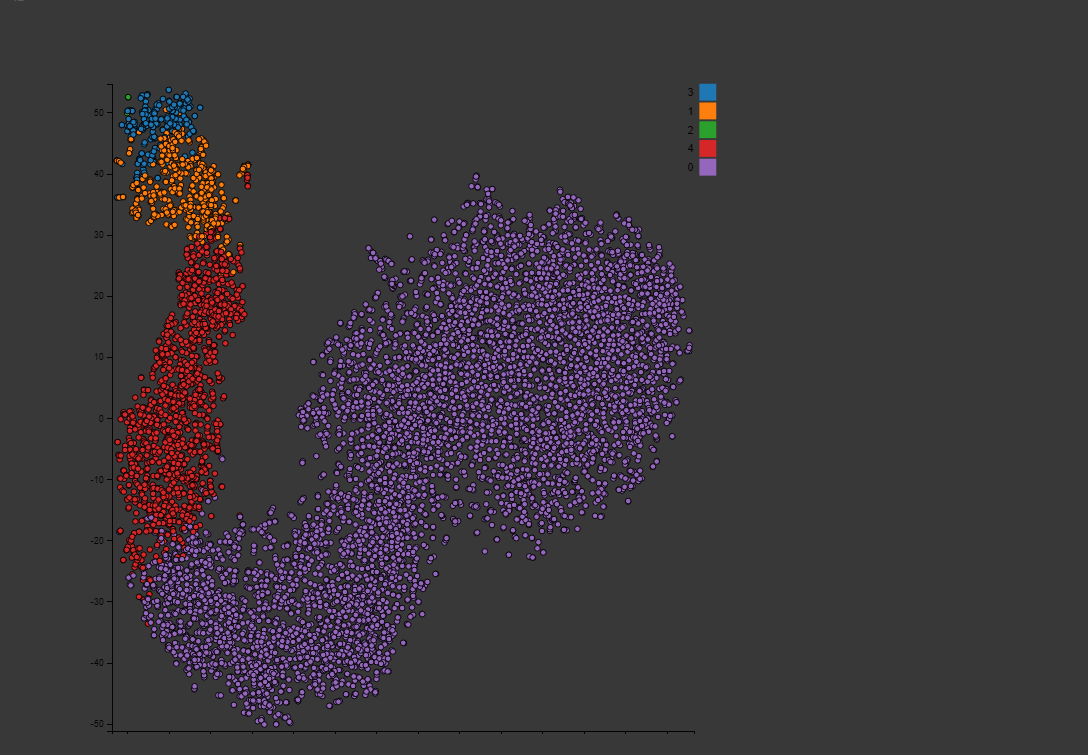

In [ ]:
#This is an autograded cell, do not edit/delete
Image('trained_scatter.png')

### **Q7** Visualizing the PRE-TRAINED vectors (1.5 points)

In this question, you'll execute the same analysis as in Q6, but on PRE-TRAINED vectors.

#### **Q7a**

Load the google vector model

(It must be downloaded as `GoogleNews-vectors-negative300` for you if you ran the first code-chunk at the top of this notebook)


In [25]:
# google_model
google_model = api.load("word2vec-google-news-300")

Downsample the pre-trained google model to anywhere between 10,000 to 25,000 words.

In [26]:
#your code here
# Downsample the model to the top 20,000 words (adjust this number as needed)
downsampled_model = google_model.key_to_index.keys()
downsampled_model = list(downsampled_model)[:20000]

Create a list of the unique set of words from this downsampled model

In [27]:
#your code here
unique_words = downsampled_model
print(unique_words)

['</s>', 'in', 'for', 'that', 'is', 'on', '##', 'The', 'with', 'said', 'was', 'the', 'at', 'not', 'as', 'it', 'be', 'from', 'by', 'are', 'I', 'have', 'he', 'will', 'has', '####', 'his', 'an', 'this', 'or', 'their', 'who', 'they', 'but', '$', 'had', 'year', 'were', 'we', 'more', '###', 'up', 'been', 'you', 'its', 'one', 'about', 'would', 'which', 'out', 'can', 'It', 'all', 'also', 'two', 'after', 'first', 'He', 'do', 'time', 'than', 'when', 'We', 'over', 'last', 'new', 'other', 'her', 'people', 'into', 'In', 'our', 'there', 'A', 'she', 'could', 'just', 'years', 'some', 'U.S.', 'three', 'million', 'them', 'what', 'But', 'so', 'no', 'like', 'if', 'only', 'percent', 'get', 'did', 'him', 'game', 'back', 'because', 'now', '#.#', 'before', 'company', 'any', 'team', 'against', 'off', 'This', 'most', 'made', 'through', 'make', 'second', 'state', 'well', 'day', 'season', 'says', 'week', 'where', 'while', 'down', 'being', 'government', 'your', '#-#', 'home', 'going', 'my', 'good', 'They', "'re", 

Extract respective vectors corresponding to the words in the down-sampled, pre-trained model

In [28]:
#your code here
vector_list = [google_model[word] for word in unique_words]
print(vector_list[:3])  # Display the first 3 vectors as a check

[array([ 1.1291504e-03, -8.9645386e-04,  3.1852722e-04,  1.5335083e-03,
        1.1062622e-03, -1.4038086e-03, -3.0517578e-05, -4.1961670e-04,
       -5.7601929e-04,  1.0757446e-03, -1.0223389e-03, -6.1798096e-04,
       -7.5531006e-04,  1.4038086e-03, -1.6403198e-03, -6.3323975e-04,
        1.6326904e-03, -1.0070801e-03, -1.2664795e-03,  6.5231323e-04,
       -4.1580200e-04, -1.0757446e-03,  1.5258789e-03, -2.7465820e-04,
        1.4019012e-04,  1.5716553e-03,  1.3580322e-03, -8.3160400e-04,
       -1.4038086e-03,  1.5792847e-03,  2.5367737e-04, -7.3242188e-04,
       -1.0538101e-04, -1.1672974e-03,  1.5792847e-03,  6.5612793e-04,
       -6.5994263e-04,  2.9206276e-06,  1.1291504e-03,  4.2724609e-04,
       -3.7002563e-04, -1.1520386e-03,  1.2664795e-03, -3.5166740e-06,
        2.6512146e-04, -4.0245056e-04,  1.4114380e-04, -3.3617020e-05,
        7.5912476e-04, -5.1879883e-04, -7.1048737e-05,  6.0272217e-04,
       -5.0735474e-04, -1.6250610e-03, -4.3678284e-04, -9.9182129e-04,
     

#### **Q7b**

Run Kmeans clustering on the pre-trained word vectors. Make sure to use the word vectors from the pre-trained model.

In [29]:
#your code here
from sklearn.cluster import KMeans
import numpy as np

# Convert vector_list to a numpy array for clustering
X = np.array(vector_list)

# Define the number of clusters
num_clusters = 5  # Adjust this as needed

# Run K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign each word to a cluster
word_clusters = {word: kmeans.labels_[i] for i, word in enumerate(unique_words)}

# Display words in each cluster
for cluster in range(num_clusters):
    words_in_cluster = [word for word, label in word_clusters.items() if label == cluster]
    print(f"Cluster {cluster}: {words_in_cluster[:10]}")  # Display first 10 words in each cluster as a sample


Cluster 0: ['####', '$', '###', 'A', '#.#', '%', 'By', '#.##', '1', 'AP']
Cluster 1: ['game', 'team', 'season', '#-#', 'games', 'New_York', 'County', 'John', 'coach', 'scored']
Cluster 2: ['</s>', 'in', 'for', 'that', 'is', 'on', '##', 'The', 'with', 'said']
Cluster 3: ['looking_statements', 'differ_materially', 'Sports_Writer', 'cause_actual', 'Private_Securities_Litigation_Reform', 'Staff_Writer', 'Forward_looking', 'report_abuse_button', 'Associated_Press_writers', 'Editing']
Cluster 4: ['people', 'she', 'U.S.', 'company', 'state', 'government', 'business', 'market', 'information', 'police']


#### **Q7c**
Reduce the dimensionality of the word vectors from the pre-trained model using tSNE

In [30]:
#your code here
from sklearn.manifold import TSNE
import numpy as np

X = np.array(vector_list)
tsne = TSNE(n_components=2, random_state=42)
word_vectors_2d = tsne.fit_transform(X)
print("Shape of word vectors after t-SNE:", word_vectors_2d.shape)

Shape of word vectors after t-SNE: (20000, 2)


#### **Q7d**

#### Create a dataframe with the following columns using the pre-trained vectors and corpus:

| Column |Description|
| --- | --- |
| x | the first dimension of result from TSNE |
| y | the second dimension of result from TSNE |
| Feature 1 | the word corresponding to the vector |
| Feature 2 | the kmeans cluster label |

<br>

Below is a sample of what the dataframe could look like:

|x	|y|	Feature 1|	Feature 2|
| --- | --- | --- | --- |
|	7.154159	|9.251100|	lips	|8|
|	-53.254147|	-13.514915|	them|	9|
|	34.049191	|-13.402843|	topic|	0|
|	-32.515320|	28.699677|	sofa|	24|
|	13.006302	|-4.270626|	half-past|	21|

In [31]:
#your code here
import pandas as pd

df = pd.DataFrame({
    'x': word_vectors_2d[:, 0],               # First dimension of t-SNE
    'y': word_vectors_2d[:, 1],               # Second dimension of t-SNE
    'Feature 1': unique_words,                # Corresponding word
    'Feature 2': [word_clusters[word] for word in unique_words]  # K-means cluster label
})

print(df.head())

           x         y Feature 1  Feature 2
0   8.593942  6.747931      </s>          2
1   7.879757  3.900310        in          2
2  10.033459  7.872796       for          2
3  13.094385  7.696223      that          2
4  45.475636 -0.755153        is          2


#### **Q7e: Visualization**

In this question, you are required to visualize and explore the reduced dataset **from the pretrained model** you created in Q7d using the [d3-scatterplot](https://github.com/CAHLR/d3-scatterplot) library.

Note: The first code-chunk at the top in this notebook clones the libary from github. Make sure that it has been executed before you proceed.

##### Save your dataset as a tsv file 'd3-scatterplot/google_mytext.tsv'

Example:

```
google_df.to_csv('d3-scatterplot/google_mytext.tsv', sep='\t', index=False)
```


Note 1: The TSV file needs to be stored in the `d3-scatterplot` folder so that the d3-scatterplot library can access it.

Note 2: Make sure to save the TSV file WITHOUT the row index i.e. use `index=False`.


In [32]:
#your code here
df.to_csv('d3-scatterplot/google_mytext.tsv', sep='\t', index=False)

##### Visualize the reduced vectors by running the following code


In [33]:
def show_port(port, data_file, width=600, height=800):
  display(Javascript("""
  (async ()=>{
    fm = document.createElement('iframe')
    fm.src = await google.colab.kernel.proxyPort(%d) + '/index.html?dataset=%s'
    fm.width = '90%%'
    fm.height = '%d'
    fm.frameBorder = 0
    document.body.append(fm)
  })();
  """ % (port, data_file, height)))

port = 8001
data_file = 'google_mytext.tsv'
height = 1400

get_ipython().system_raw('cd d3-scatterplot && python3 -m http.server %d &' % port)
show_port(port, data_file, height)

<IPython.core.display.Javascript object>

Color the points by their kmeans cluster. You can do this by choosing "Feature 2" as the variable in the "Color" drop-down in the visualization.

Please include a snapshot of your visualization in the notebook. Refer to the tutorial video, and/or follow the steps below:

1) Take a snapshot of the visualization and save it on your computer with the filename `google_trained_scatter.png`

2) Upload the `google_trained_scatter.png` by clicking on the 'Files' icon on the left sidebar and clicking on the upload icon (the one with an upward arrow on top left)

3) Run the code below to display the image

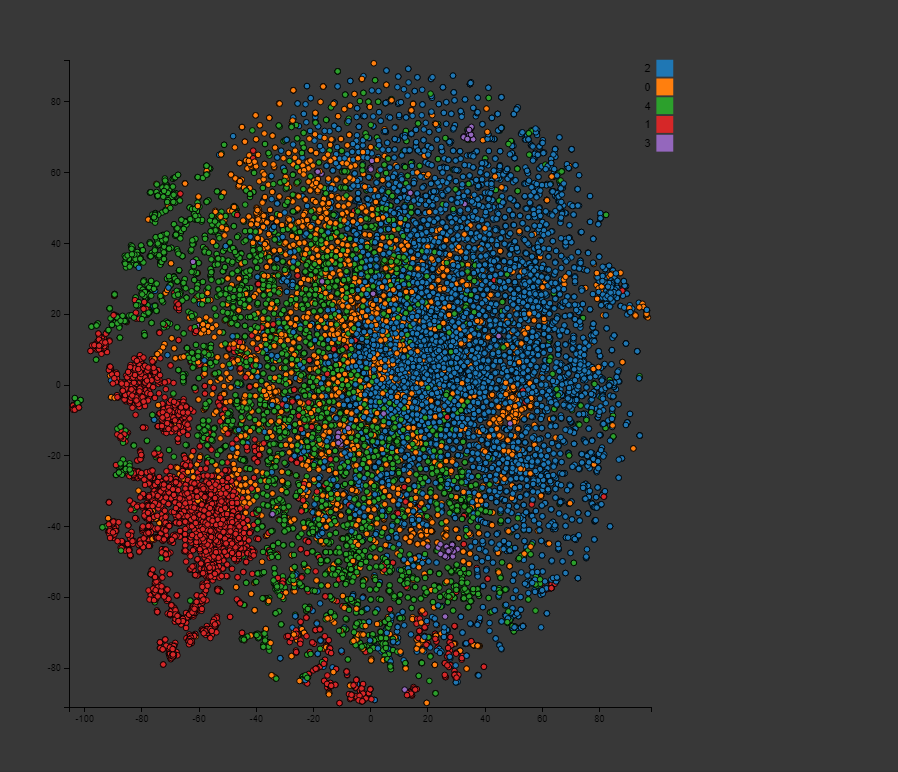

In [34]:
#This is an autograded cell, do not edit/delete
Image('google_trained_scatter.png')

### **Q8: Exploration** (0.5 points)

This is an open-ended question.

On the visualizations in Q6 & Q7, lasso-select a group of points with the left mouse button and look at summaries of the group on the right-side of the plot. (Refer to the tutorial video for a demo on the lasso selection). Also look at the words / features of the selected points.

Comment on at least 3 patterns / similarities you see in the selected words in the visualization for the pre-trained vectors and the vectors trained on your corpus. Are you able to find any group of points that are close to each other in the 2D space that also have semantic similarity?

--your answer here--
 In Q6, the cluster for words such as "shook," "mutual," and "unsullied," the theme of either emotional states or relational descriptors became apparent. The exact words are also quite close to each other in 2D space, again to show that indeed the model trained from this corpus does capture a fine sense of words relating to relationships and emotions. This cluster represents words likely to have co-occurred or occurred in similar contexts in the corpus. It shows the sensitivity of the model to semantic groupings peculiar to the dataset.

 Similarly, Q7 visualization, the cluster containing words like "reprinted," "incumbents," and "handcuffs" chooses words from a context which is more institutional, or we might say, formal, pertaining to politics, publishing, or legal matters. We can see from the proximity of these words that the pre-trained model has acquired some general knowledge of the words employed in more formal or procedural contexts, where such terms as those mentioned above may be more often called upon. This observation is a reflection of the wide-ranging knowledge of professional vocabulary that the model has, probably acquired through its training on diverse texts.

 In both visualizations, there is a dense central cluster and sparser peripheral clusters, but with some very minor differences. While for Q6, the corpus specific model has in its center more general terms and on the periphery more nuanced or specific terms related to emotions or interpersonal relationships, Q7 pre-trained model displays an overall different distribution, dense clusters of words originating from various contexts. This may refer to the fact that the pattern of the pre-trained model is richer in vocabulary across diverse topics, while the model trained on the corpus is focused on knowledge related to its dataset.



